Text(0.5, 1.0, "$ {y}' = - \\frac{x^2}{1 - x^2 - y^2} $")

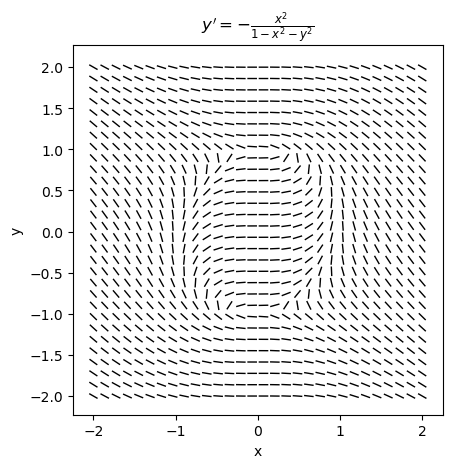

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# Direction Field
# Membuat bidang arah untuk persamaan diferensial di domain x,y.
def direction_field(x_min, x_max, y_min, y_max, n_step, lenght, fun, ax):
   
    # Hindari warning pembagian dengan nol saat slope menghitung.
    np.seterr(divide='ignore', invalid='ignore') # Mengabaikan peringatan pembagian dengan nol dan nilai tidak valid saat menghitung slope.
    
    x = np.linspace(x_min, x_max, n_step) # Membuat array x dengan n_step titik antara x_min dan x_max.
    y = np.linspace(y_min, y_max, n_step) # Membuat array y dengan n_step titik antara y_min dan y_max.
    X, Y = np.meshgrid(x, y) # Membuat grid 2D dari array x dan y.
    slope = fun(X,Y)
    # Ganti nilai tak hingga dengan nilai besar agar tetap bisa diplot.
    slope = np.where(slope == np.inf, 10**3, slope) # Ganti nilai negatif tak hingga dengan nilai negatif besar agar tetap bisa diplot.
    slope = np.where(slope == -np.inf, -10**3, slope) # Ganti nilai positif tak hingga dengan nilai positif besar agar tetap bisa diplot.
    delta = lenght * np.cos(np.arctan(slope)) # Menghitung delta untuk menentukan panjang segmen arah berdasarkan slope.
    X1 = X - delta # Menghitung koordinat X1 untuk segmen arah.
    X2 = X + delta # Menghitung koordinat X2 untuk segmen arah.
    Y1 = slope*(X1-X)+Y # Menghitung koordinat Y1 untuk segmen arah.
    Y2 = slope*(X2-X)+Y # Menghitung koordinat Y2 untuk segmen arah.
    ax.plot([X1.ravel(), X2.ravel()], [Y1.ravel(), Y2.ravel()], 'k-', linewidth=1) # Plot segmen arah pada bidang arah.

# Definisi persamaan diferensial y' = x^2 / (1 - x^2 - y^2).
def my_ode(x, y):
    dy_dx =  x**2 / (1 - x**2 - y**2) # Menghitung nilai turunan y' berdasarkan persamaan diferensial yang diberikan.
    return dy_dx # Mengembalikan nilai turunan y' yang telah dihitung.

# Buat plot bidang arah menggunakan fungsi di atas.
fig, ax1 = plt.subplots()# Buat plot bidang arah menggunakan fungsi direction_field dengan parameter yang sesuai.
direction_field(x_min=-2, x_max=2, y_min=-2, y_max=2, n_step=30, lenght=0.05, fun=my_ode, ax=ax1) # Buat plot bidang arah menggunakan fungsi direction_field dengan parameter yang sesuai.
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('square')

ax1.set_title(r"$ {y}' = - \frac{x^2}{1 - x^2 - y^2} $")     

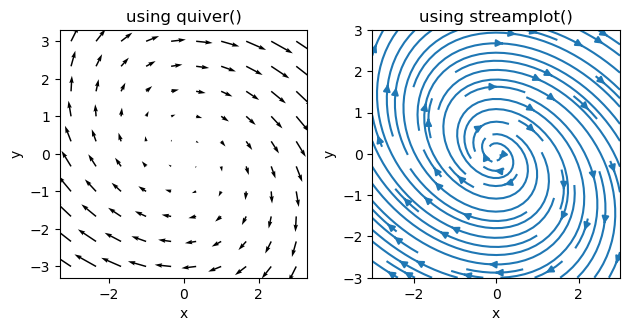

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

# Buat grid x dan y untuk memvisualisasikan medan vektor.
x = np.linspace(-3, 3, 10) # Membuat array x dengan 10 titik antara -3 dan 3.
y = x # Membuat array y yang sama dengan x agar grid berbentuk kotak.
X, Y = np.meshgrid(x, y) # Membuat grid 2D dari array x dan y.

# Definisikan komponen vektor dx/dt dan dy/dt pada setiap titik grid.
dx_dt = X + 2*Y # Komponen arah horizontal.
dy_dt = - 2*X   # Komponen arah vertikal.

# Buat dua subplot untuk membandingkan dua cara visualisasi medan vektor.
fig = plt.figure() 
ax1 = fig.add_subplot(1, 2, 1) # Subplot pertama untuk quiver.
ax1.quiver(X, Y, dx_dt, dy_dt) # Gambar panah vektor menggunakan quiver().
ax1.set_title('using quiver()') # Judul untuk subplot quiver.
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('')

ax2 = fig.add_subplot(1, 2, 2) # Subplot kedua untuk streamplot.
ax2.streamplot(X, Y, dx_dt, dy_dt) # Gambar garis aliran dari medan vektor.
ax2.set_title('using streamplot()') # Judul untuk subplot streamplot.
ax2.set_xlabel('x') 
ax2.set_ylabel('y')
ax2.axis('square')

fig.tight_layout() # Rapikan layout agar subplot tidak saling tumpang tindih.

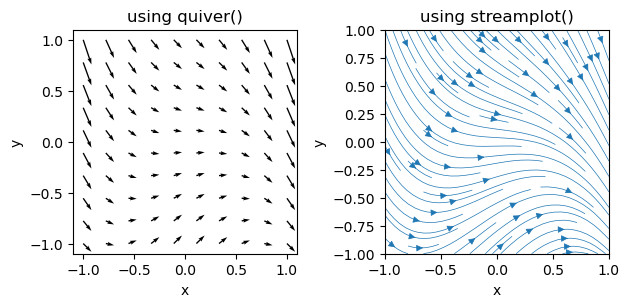

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

# Buat grid x dan y untuk sistem arah nonlinier.
x = np.linspace(-1, 1, 10) 
y = x

# Membuat grid 2D untuk titik-titik bidang.
X, Y = np.meshgrid(x, y) 

# Komponen vektor untuk setiap posisi.
dx_dt = np.ones_like(X) # Komponen horizontal konstan.
dy_dt = - Y - 2 * X**2 # Komponen vertikal tergantung pada X dan Y.

# Membandingkan dua cara visualisasi medan vektor.
fig = plt.figure() 
ax1 = fig.add_subplot(1, 2, 1) # Subplot pertama: quiver.
ax1.quiver(X, Y, dx_dt, dy_dt) # Plot panah vektor.
ax1.set_title('using quiver()') # Judul subplot pertama.
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('square')

ax2 = fig.add_subplot(1, 2, 2) # Subplot kedua: streamplot.
ax2.streamplot(X, Y, dx_dt, dy_dt, linewidth=0.5) # Plot garis aliran.
ax2.set_title('using streamplot()') # Judul subplot kedua.
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.axis('square')

fig.tight_layout() # Rapikan tata letak subplot.

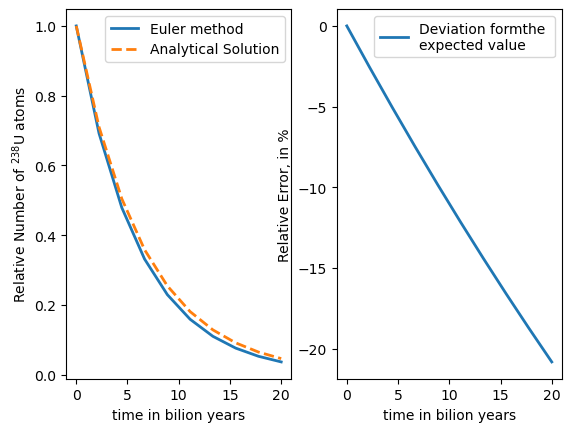

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Euler Method untuk model peluruhan eksponensial.
def euler_method(n0, decay_const, t_final, n_t_steps):
    iterations = n_t_steps # Jumlah iterasi yang akan dilakukan, sama dengan jumlah langkah waktu.
    delta_t = t_final/n_t_steps # Besar langkah waktu yang digunakan dalam metode Euler.
    t1 = np.linspace(0, iterations*delta_t, iterations) # Membuat array waktu dari 0 hingga t_final dengan jumlah titik sebanyak iterations.
    n1 = np.zeros(t1.shape, float)  # Inisialisasi array untuk menyimpan jumlah atom pada setiap langkah waktu, diisi dengan nol.
    n1[0]=n0 
    for i in range(0,len(t1)-1):
        # Update Euler maju pada setiap langkah waktu.
        n1[i+1] = n1[i] * (1 - decay_const * delta_t ) # Menghitung jumlah atom pada langkah waktu berikutnya menggunakan metode Euler maju.
    n1r = n1/n0 # Menghitung rasio jumlah atom saat ini terhadap jumlah awal untuk mendapatkan nilai relatif.
    return n1, n1r, t1 

ne, ner, te = euler_method(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10) # Menghitung solusi menggunakan metode Euler untuk model peluruhan eksponensial dengan parameter yang diberikan.

# Solusi analitik pada titik waktu yang sama untuk perbandingan.
def analytical_solution(n0, decay_const, t_final, n_t_steps):
    
    intermediate_points = n_t_steps # Jumlah titik waktu yang sama dengan metode Euler untuk perbandingan.
    delta_t = t_final/n_t_steps # Besar langkah waktu yang digunakan untuk solusi analitik, sama dengan metode Euler.
    t2 = np.linspace(0, intermediate_points*delta_t, intermediate_points) # Membuat array waktu untuk solusi analitik dengan jumlah titik yang sama dengan metode Euler.
    n2 = n0 * np.exp(-decay_const * t2 ) # Menghitung jumlah atom pada setiap titik waktu menggunakan rumus peluruhan eksponensial.
    n2r = n2/n0 # Menghitung rasio jumlah atom saat ini terhadap jumlah awal untuk mendapatkan nilai relatif pada solusi analitik.
    return n2, n2r, t2 

na, nar, ta = analytical_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10) # Menghitung solusi analitik untuk perbandingan dengan metode Euler.

euler_rel_error = 100*(ne-na)/na # Menghitung error relatif antara solusi Euler dan solusi analitik dalam persen.

fig = plt.figure() # Membuat objek figure untuk plotting.
ax1 = fig.add_subplot(1, 2, 1) # Subplot pertama untuk membandingkan solusi Euler dan solusi analitik.
ax1.plot(te, ner, linestyle="-", linewidth=2, label='Euler method') # Plot solusi Euler dengan garis solid.
ax1.plot(ta, nar, linestyle="--", linewidth=2, label='Analytical Solution') # Plot solusi analitik dengan garis putus-putus untuk membedakan dari solusi Euler.
ax1.set_ylabel('Relative Number of $^{238}$U atoms') # Label untuk sumbu y yang menunjukkan jumlah relatif atom uranium-238.
ax1.set_xlabel('time in bilion years')# Label untuk sumbu x yang menunjukkan waktu dalam miliar tahun.
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2) # Subplot kedua untuk menampilkan error relatif antara solusi Euler dan solusi analitik.
ax2.plot(te, euler_rel_error, linestyle="-", linewidth=2, label='Deviation formthe \nexpected value') # Plot error relatif dengan garis solid dan label yang menjelaskan bahwa ini adalah deviasi dari nilai yang diharapkan.
ax2.set_ylabel('Relative Error, in %') # Label untuk sumbu y yang menunjukkan error relatif dalam persen.
ax2.set_xlabel('time in bilion years')# Label untuk sumbu x yang menunjukkan waktu dalam miliar tahun.
ax2.legend()


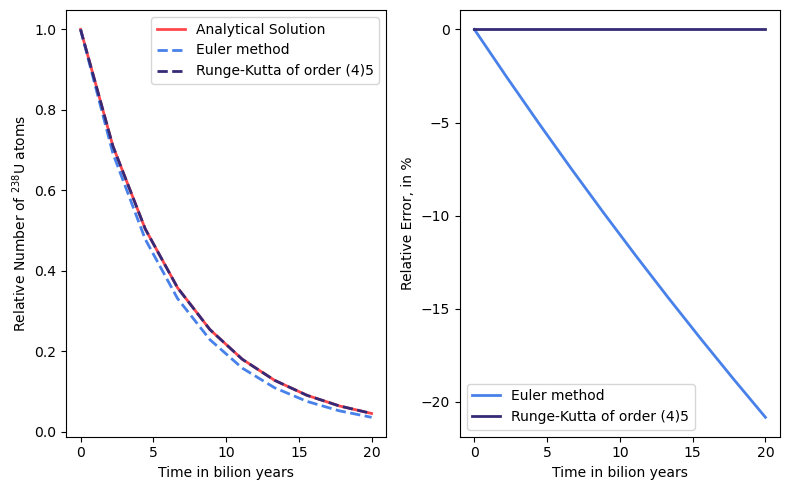

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import ode

# using scipy.integrate.ode
def ode_sol(n0, decay_const, t_final, n_t_steps):
    intermediate_points = n_t_steps # Jumlah titik waktu yang sama dengan metode Euler untuk perbandingan.
    t3 = np.linspace(0,t_final, intermediate_points) # Membuat array waktu untuk solusi ODE dengan jumlah titik yang sama dengan metode Euler.
    n3 = np.zeros(t3.shape, float) # Inisialisasi array untuk menyimpan jumlah atom pada setiap langkah waktu, diisi dengan nol.
    def f(t, y, decay_const):
        return  - decay_const * y  # Fungsi yang mendefinisikan persamaan diferensial untuk peluruhan eksponensial, di mana turunan jumlah atom terhadap waktu adalah negatif dari konstanta peluruhan dikalikan dengan jumlah atom saat ini.
    solver = ode(f).set_integrator('dopri5') # runge-kutta of order (4)5 
    y0 = n0 
    t0 = 0
    solver.set_initial_value(y0, t0) # Mengatur nilai awal untuk solver ODE, yaitu jumlah atom awal (y0) dan waktu awal (t0).
    solver.set_f_params(decay_const) # Mengatur parameter tambahan untuk fungsi ODE, yaitu konstanta peluruhan yang akan digunakan dalam perhitungan.
    k=1
    n3[0] = n0 # Menyimpan jumlah atom awal pada indeks pertama array n3 sebelum memulai iterasi untuk integrasi ODE.
    while solver.successful() and solver.t < t_final:
        n3[k] = solver.integrate(t3[k])[0] # Melakukan integrasi ODE untuk mendapatkan jumlah atom pada waktu t3[k] dan menyimpannya dalam array n3 pada indeks k.
        k += 1  # k = k + 1 # Increment indeks k untuk melanjutkan ke titik waktu berikutnya dalam array t3.
    n3r = n3 / n0 # Menghitung rasio jumlah atom saat ini terhadap jumlah awal untuk mendapatkan nilai relatif pada solusi ODE.
    return n3, n3r, t3 

# Analytical solution
na, nar, ta = analytical_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10)# Solusi analitik untuk perbandingan dengan solusi ODE.
# Euler method
ne, ner, te = euler_method(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10) # Solusi menggunakan metode Euler untuk perbandingan dengan solusi ODE.
nuler_rel_error = 100*(ne-na)/na # Menghitung error relatif antara solusi Euler dan solusi analitik dalam persen untuk perbandingan dengan solusi ODE.
# runge-kutta of order (4)5
n_ode, n_oder, tode = ode_sol(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10) # Solusi menggunakan metode Runge-Kutta untuk perbandingan dengan solusi Euler dan solusi analitik.
ode_rel_error = 100*(n_ode - na) / na # Menghitung error relatif antara solusi ODE dan solusi analitik dalam persen untuk perbandingan dengan solusi Euler.

# Make the plot
fig = plt.figure(figsize=(8,5)) # Membuat objek figure dengan ukuran yang ditentukan untuk plotting hasil perbandingan antara solusi Euler, solusi ODE, dan solusi analitik.
ax1 = fig.add_subplot(1, 2, 1) # Subplot pertama untuk membandingkan solusi Euler, solusi ODE, dan solusi analitik.
ax1.plot(ta, nar, linestyle="-", linewidth=2, label='Analytical Solution', c='#ff464a') # Plot solusi analitik dengan garis solid dan warna merah untuk membedakan dari solusi numerik.
ax1.plot(te, ner, linestyle="--", linewidth=2, label='Euler method', c='#4881e9') # Plot solusi Euler dengan garis putus-putus dan warna biru untuk membedakan dari solusi analitik.
ax1.plot(tode, n_oder, linestyle="--", linewidth=2, label='Runge-Kutta of order (4)5', c='#342a77') # Plot solusi ODE dengan garis putus-putus dan warna ungu untuk membedakan dari solusi Euler dan solusi analitik.
ax1.set_ylabel('Relative Number of $^{238}$U atoms') # Label untuk sumbu y yang menunjukkan jumlah relatif atom uranium-238.
ax1.set_xlabel('Time in bilion years')   # Label untuk sumbu x yang menunjukkan waktu dalam miliar tahun.
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2) # Subplot kedua untuk menampilkan error relatif antara solusi Euler, solusi ODE, dan solusi analitik.
ax2.plot(te, euler_rel_error, linestyle="-", linewidth=2, c='#4881e9', label='Euler method') # Plot error relatif untuk solusi Euler dengan garis solid dan warna biru untuk membedakan dari solusi ODE.
ax2.plot(tode, ode_rel_error, linestyle="-", linewidth=2, c='#342a77', label='Runge-Kutta of order (4)5') # Plot error relatif untuk solusi ODE dengan garis solid dan warna ungu untuk membedakan dari solusi Euler.
ax2.set_ylabel('Relative Error, in %') # Label untuk sumbu y yang menunjukkan error relatif dalam persen.
ax2.set_xlabel('Time in bilion years')   # Label untuk sumbu x yang menunjukkan waktu dalam miliar tahun.
ax2.legend()

fig.tight_layout()





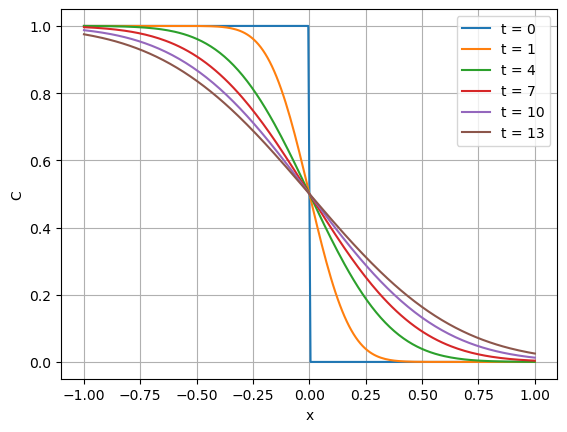

In [ ]:
import numpy as np
from scipy import special
import matplotlib.pyplot as plt

def plane_diff_1d(t, D, x0=0, xmin=-1, xmax=1, c_left=1, c_right=0, num_points=200):
    
     n = num_points # Jumlah titik yang digunakan untuk membuat array x antara xmin dan xmax.
     x = np.linspace(xmin, xmax, n) # Membuat array x dengan n titik antara xmin dan xmax untuk memvisualisasikan distribusi konsentrasi pada bidang satu dimensi.
     delta_c = c_left - c_right # Menghitung perbedaan konsentrasi antara sisi kiri dan sisi kanan untuk digunakan dalam perhitungan distribusi konsentrasi.
     
     c0 = np.piecewise(x, [x < x0, x >= x0], [c_left, c_right]) # Membuat array c0 yang berisi nilai konsentrasi awal pada setiap titik x, di mana nilai konsentrasi adalah c_left untuk x < x0 dan c_right untuk x >= x0.
     c = 0.5 * delta_c * (special.erfc((x - x0)/(2 * np.sqrt(D * t)))) # Menghitung distribusi konsentrasi c pada setiap titik x dan waktu t menggunakan fungsi erfc dari modul special untuk menyelesaikan persamaan difusi satu dimensi.
  
     return x, c, c0 # Mengembalikan array x, distribusi konsentrasi c pada waktu t, dan distribusi konsentrasi awal c0 untuk digunakan dalam visualisasi.

D = 0.01 # Diffusion coefficient # Koefisien difusi yang digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.

fig, ax = plt.subplots() 

for t in range(1, 14, 3):

    x, c, c0 = plane_diff_1d(t=t, D=D) # Menghitung distribusi konsentrasi pada bidang satu dimensi untuk waktu t yang berbeda menggunakan fungsi plane_diff_1d dan menyimpan hasilnya dalam variabel x, c, dan c0.
    if t==1:
        leg = "t = " + str(t)# Membuat label untuk waktu t = 1 untuk digunakan dalam legenda pada plot.
        plt.plot(x, c0, label="t = 0") # Plot distribusi konsentrasi awal c0 dengan label "t = 0" untuk menunjukkan kondisi awal sebelum difusi terjadi.
    leg = "t = " + str(t) # Membuat label untuk waktu t yang berbeda untuk digunakan dalam legenda pada plot. 
    ax.plot(x, c, label=leg) # Plot distribusi konsentrasi c pada waktu t dengan label yang sesuai untuk membedakan antara waktu yang berbeda dalam visualisasi.
    
ax.grid()
ax.set_xlabel('x')
ax.set_ylabel('C')  
ax.legend()



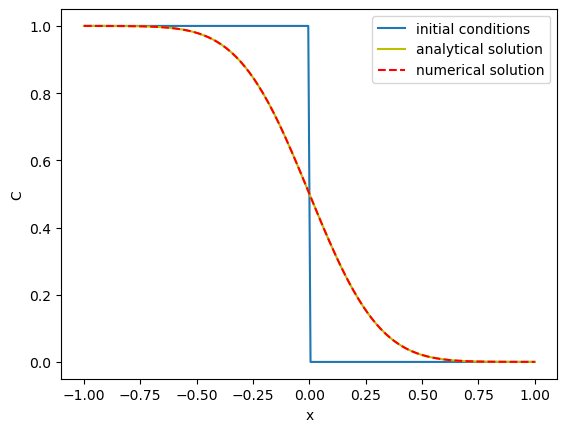

In [ ]:
def ftcs(u, D, h, dt):
    
    d2u_dx2 = np.zeros(u.shape, float) # Inisialisasi array untuk menyimpan nilai turunan kedua dari u terhadap x, diisi dengan nol.
    for i in range(1,len(u)-1): 
        # Central difference scheme in space#untuk menghitung turunan kedua dari u terhadap x pada setiap titik i, kecuali pada titik pertama dan terakhir yang akan ditangani dengan kondisi batas Neumann.
        d2u_dx2[i] = (u[i+1] - 2*u[i] + u[i-1]) / h**2# Menghitung turunan kedua dari u terhadap x pada titik i menggunakan skema beda pusat, di mana u[i+1] adalah nilai u pada titik berikutnya, u[i] adalah nilai u pada titik saat ini, dan u[i-1] adalah nilai u pada titik sebelumnya, dibagi dengan kuadrat dari langkah ruang h untuk mendapatkan nilai turunan kedua.
        
    # Neuman boundary conditions at i=0 and i=len(u)-1
    i=0 # Menangani kondisi batas Neumann pada titik pertama (i=0) dengan menggunakan nilai u pada titik berikutnya untuk menghitung turunan kedua.
    d2u_dx2[i] = (u[i+1] - 2 * u[i] + u[i]) / h**2 # Menghitung turunan kedua dari u terhadap x pada titik pertama dengan menggunakan nilai u pada titik berikutnya dan nilai u pada titik saat ini untuk memenuhi kondisi batas Neumann.
    i=len(u)-1  # Menangani kondisi batas Neumann pada titik terakhir (i=len(u)-1) dengan menggunakan nilai u pada titik sebelumnya untuk menghitung turunan kedua.
    d2u_dx2[i] = (u[i] - 2 * u[i] + u[i-1]) / h**2  # Menghitung turunan kedua dari u terhadap x pada titik terakhir dengan menggunakan nilai u pada titik saat ini dan nilai u pada titik sebelumnya untuk memenuhi kondisi batas Neumann.
    
    # Euler method for the time domain
    u1 = u + dt * D * d2u_dx2 # Mengupdate
    return u1   
    
dt = 0.001  #step size of time 
tf = 3

def compute_d_const(u, d, h, dt, tf): # Fungsi untuk menghitung distribusi konsentrasi pada bidang satu dimensi menggunakan metode FTCS (Forward Time Centered Space) untuk persamaan difusi dengan koefisien difusi d, langkah ruang h, langkah waktu dt, dan waktu akhir tf.
    
    nsteps = tf/dt # Menghitung jumlah langkah waktu yang diperlukan untuk mencapai waktu akhir tf dengan menggunakan langkah waktu dt.
    u1 = u # Inisialisasi array u1 dengan nilai awal u untuk memulai iterasi metode FTCS.
    for i in range(int(nsteps)):
        u1 =  ftcs(u1, D, h, dt) # Melakukan iterasi metode FTCS untuk menghitung distribusi konsentrasi pada setiap langkah waktu, di mana u1 diperbarui dengan hasil dari fungsi ftcs yang menghitung nilai u pada langkah waktu berikutnya berdasarkan nilai u saat ini, koefisien difusi D, langkah ruang h, dan langkah waktu dt.
    return u1

x, c, c0 = plane_diff_1d(t=tf, D=D) # Menghitung distribusi konsentrasi pada bidang satu dimensi untuk waktu tf menggunakan fungsi plane_diff_1d dan menyimpan hasilnya dalam variabel x, c, dan c0 untuk digunakan dalam perbandingan dengan solusi numerik yang dihitung menggunakan metode FTCS.

h = x[1] - x[0] # Menghitung langkah ruang h berdasarkan perbedaan antara dua titik pertama dalam array x, yang digunakan dalam metode FTCS untuk menghitung turunan kedua dari u terhadap x.
u = c0 # intial conditions # Menetapkan nilai awal u dengan distribusi konsentrasi awal c0 untuk memulai iterasi metode FTCS dalam menghitung distribusi konsentrasi pada bidang satu dimensi.
c1 = compute_d_const(u, D, h, dt, tf) # Menghitung distribusi konsentrasi pada bidang satu dimensi menggunakan metode FTCS dengan memanggil fungsi compute_d_const yang melakukan iterasi metode FTCS untuk menghitung distribusi konsentrasi pada setiap langkah waktu hingga mencapai waktu akhir tf, dan menyimpan hasilnya dalam variabel c1 untuk dibandingkan dengan solusi analitik c.

fig, ax = plt.subplots()  
ax.plot(x,c0, label='initial conditions') # Plot distribusi konsentrasi awal c0 dengan label "initial conditions" untuk menunjukkan kondisi awal sebelum difusi terjadi.
ax.plot(x,c,'y', label='analytical solution') # Plot distribusi konsentrasi analitik c dengan warna kuning dan label "analytical solution" untuk membedakan dari solusi numerik yang dihitung menggunakan metode FTCS.
ax.plot(x,c1,'r--', label='numerical solution')  # Plot distribusi konsentrasi numerik c1 yang dihitung menggunakan metode FTCS dengan garis putus-putus merah dan label "numerical solution" untuk membedakan dari solusi analitik.
ax.set_xlabel('x') # Label untuk sumbu x yang menunjukkan posisi pada bidang satu dimensi.
ax.set_ylabel('C')    # Label untuk sumbu y yang menunjukkan konsentrasi pada bidang satu dimensi.
ax.legend()


In [ ]:
def numpy_ftcs(u, D, h, dt):

    d2u_dx2 = np.zeros(u.shape, float) # Inisialisasi array untuk menyimpan nilai turunan kedua dari u terhadap x, diisi dengan nol, menggunakan fungsi zeros dari modul numpy untuk membuat array dengan bentuk yang sama dengan u.
    d2u_dx2[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / h**2 # Menghitung turunan kedua dari u terhadap x pada setiap titik i, kecuali pada titik pertama dan terakhir, menggunakan operasi slicing pada array u untuk mengakses nilai pada titik berikutnya (u[2:]), titik saat ini (u[1:-1]), dan titik sebelumnya (u[:-2]), dibagi dengan kuadrat dari langkah ruang h untuk mendapatkan nilai turunan kedua.

    # Neuman boundary conditions at i=0 and i=len(u)-1
    i = 0 
    d2u_dx2[i] = (u[i+1] - 2 * u[i] + u[i]) / h**2 # Menghitung turunan kedua dari u terhadap x pada titik pertama dengan menggunakan nilai u pada titik berikutnya dan nilai u pada titik saat ini untuk memenuhi kondisi batas Neumann.
    i = len(u)-1 # Menangani kondisi batas Neumann pada titik terakhir (i=len(u)-1) dengan menggunakan nilai u pada titik sebelumnya untuk menghitung turunan kedua.
    d2u_dx2[i] = (u[i] - 2 * u[i] + u[i-1]) / h**2 # Menghitung turunan kedua dari u terhadap x pada titik terakhir dengan menggunakan nilai u pada titik saat ini dan nilai u pada titik sebelumnya untuk memenuhi kondisi batas Neumann.

    # Euler method for the time domain
    u1 = u + dt * D * d2u_dx2
    return u1


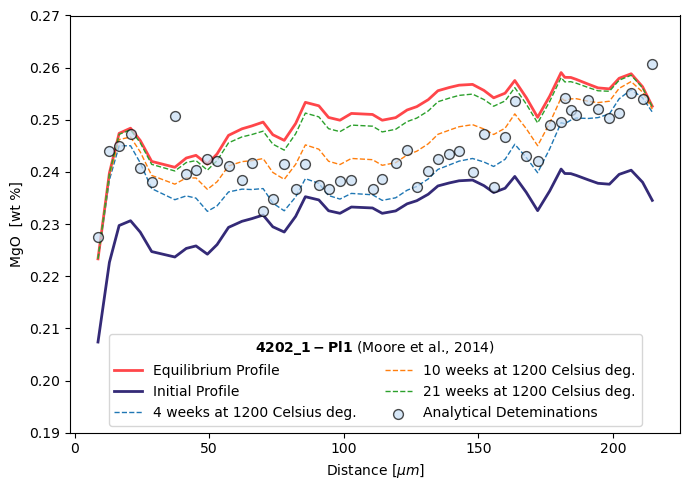

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Model parameters
T = 1200.0 # Temperature in Celsius # Temperatur dalam derajat Celsius yang digunakan dalam perhitungan difusi dan distribusi konsentrasi pada bidang satu dimensi.
dx = 4.12 # average distance in micron among the analyses # Jarak rata-rata dalam mikrometer antara titik-titik analisis yang digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
dt = 0.9 * 1e4
RT = 8.3144 * (T + 273.15) # Nilai konstanta gas ideal R dikalikan dengan suhu dalam Kelvin (T + 273.15) untuk digunakan dalam perhitungan distribusi konsentrasi dan koefisien difusi pada bidang satu dimensi.
R = dt / dx ** 2

# Initial Conditions
my_dataset = pd.read_excel('Moore_Phd.xlsx') 
my_distance = my_dataset.Distance.values # Jarak dalam mikrometer yang diambil dari dataset untuk digunakan sebagai sumbu x dalam visualisasi distribusi konsentrasi pada bidang satu dimensi.
Mg_C = my_dataset.MgO.values # Konsentrasi MgO dalam persen berat yang diambil dari dataset untuk digunakan sebagai data titik dalam visualisasi distribusi konsentrasi pada bidang satu dimensi.
An = my_dataset.An_mol_percent.values # Konsentrasi An dalam persen mol yang diambil dari dataset untuk digunakan dalam perhitungan distribusi konsentrasi dan koefisien difusi pada bidang satu dimensi.
An = An / 100 # Mengubah konsentrasi An dari persen mol menjadi fraksi mol dengan membagi nilai An dengan 100 untuk digunakan dalam perhitungan distribusi konsentrasi dan koefisien difusi pada bidang satu dimensi.
An_unsmoothed = An
An_smoothed = np.full(len(An),0.)

# Smooting the An profile to avoid numerical artifacts
D_smoot = np.full(len(An),0.0005) # Koefisien difusi untuk proses smoothing yang digunakan untuk menghaluskan profil An agar menghindari artefak numerik dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
for i in range(2):
    An_smoothed[1:-1] =  An_unsmoothed[1:-1] + R * D_smoot[1:-1] * (An_unsmoothed[2:] - 2 * An_unsmoothed[1:-1] + An_unsmoothed[:-2]) # Melakukan iterasi untuk menghaluskan profil An dengan menggunakan metode FTCS untuk menghitung nilai An yang dihaluskan pada setiap titik, kecuali pada titik pertama dan terakhir yang akan tetap sama dengan nilai awal untuk menjaga kondisi batas.
    An_smoothed[0] = An[0] # Menetapkan nilai An yang dihaluskan pada titik pertama (index 0) sama dengan nilai An awal untuk menjaga kondisi batas pada titik pertama.
    An_smoothed[len(An)-1] = An[len(An)-1] # Menetapkan nilai An yang dihaluskan pada titik terakhir (index len(An)-1) sama dengan nilai An awal untuk menjaga kondisi batas pada titik terakhir.
    an_unsmoothed = An_smoothed

D_Mg = 2.92 * 10**(-4.1 * An_smoothed - 3.1)*np.exp(-266 * 1e3/RT)*1e12  # Eq. 8 in Costa et al., 2003
  
fig, ax = plt.subplots(figsize=(7,5)) # Membuat objek figure dan axes untuk plotting dengan ukuran yang ditentukan untuk visualisasi distribusi konsentrasi pada bidang satu dimensi.
  
# Initial and Equilibrium Profiles
A = - 21882 # Koefisien A yang digunakan dalam perhitungan koefisien distribusi K untuk profil konsentrasi pada bidang satu dimensi, berdasarkan persamaan yang diberikan dalam Moore et al., 2014.
B = - 26352 
K = np.exp((A*An_smoothed+B)/RT) # Eq. 8 in Moore et al., 2014 # Menghitung koefisien distribusi K berdasarkan konsentrasi An yang dihaluskan (An_smoothed) menggunakan persamaan yang diberikan dalam Moore et al., 2014, di mana A dan B adalah koefisien yang telah ditentukan, RT adalah konstanta gas ideal dikalikan dengan suhu dalam Kelvin, dan np.exp digunakan untuk menghitung nilai eksponensial dari hasil perhitungan tersebut.
c_eq = 8.4 * K # Eq. 7 in Moore et al., 2014 # Menghitung profil konsentrasi pada bidang satu dimensi pada kondisi kesetimbangan (c_eq) berdasarkan koefisien distribusi K menggunakan persamaan yang diberikan dalam Moore et al., 2014, di mana 8.4 adalah nilai konsentrasi MgO dalam persen berat pada kondisi kesetimbangan yang digunakan sebagai referensi dalam perhitungan.
c_init = 7.8 * K
ax.plot(my_distance, c_eq, linewidth=2, color='#ff464a', label ='Equilibrium Profile')
ax.plot(my_distance, c_init,linewidth=2,  color='#342a77', label='Initial Profile')

# The numerical solution start here
colors = ['#4881e9','#e99648','#e9486e']
t_final_weeks = np.array([4,10,21])

for t_w, color in zip(t_final_weeks,colors):

    C_Mg_new = np.full(len(c_eq),0.) # Inisialisasi array untuk menyimpan nilai konsentrasi MgO pada setiap titik setelah iterasi, diisi dengan nol, dengan panjang yang sama dengan array c_eq untuk digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    d2An = np.full(len(c_eq),0.) # Inisialisasi array untuk menyimpan nilai turunan kedua dari An terhadap x pada setiap titik, diisi dengan nol, dengan panjang yang sama dengan array c_eq untuk digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    d2C_Mg = np.full(len(c_eq),0.) # Inisialisasi array untuk menyimpan nilai turunan kedua dari C_Mg terhadap x pada setiap titik, diisi dengan nol, dengan panjang yang sama dengan array c_eq untuk digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    dD_Mg = np.full(len(c_eq),0.) # Inisialisasi array untuk menyimpan nilai turunan pertama dari D_Mg terhadap x pada setiap titik, diisi dengan nol, dengan panjang yang sama dengan array c_eq untuk digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    dC_Mg = np.full(len(c_eq),0.) # Inisialisasi array untuk menyimpan nilai turunan pertama dari C_Mg terhadap x pada setiap titik, diisi dengan nol, dengan panjang yang sama dengan array c_eq untuk digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    dAn = np.full(len(c_eq),0.) # Inisialisasi array untuk menyimpan nilai turunan pertama dari An terhadap x pada setiap titik, diisi dengan nol, dengan panjang yang sama dengan array c_eq untuk digunakan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    
    C_Mg = c_init
    t_final = int(604800 * t_w/dt) # Menghitung jumlah iterasi yang diperlukan untuk mencapai waktu akhir t_w dalam minggu dengan menggunakan langkah waktu dt, di mana 604800 adalah jumlah detik dalam satu minggu, dan hasilnya dibagi dengan dt untuk mendapatkan jumlah iterasi yang diperlukan dalam perhitungan distribusi konsentrasi pada bidang satu dimensi.
    for i in range(t_final):
        # boundary conditions: Rims are at equilibrium with melt # Menetapkan kondisi batas untuk konsentrasi MgO pada titik pertama dan terakhir (rim) agar tetap sama dengan nilai konsentrasi pada kondisi kesetimbangan (c_eq) untuk menjaga kondisi batas pada bidang satu dimensi selama iterasi perhitungan distribusi konsentrasi.
        C_Mg_new[0] = c_eq[0] # Menetapkan nilai konsentrasi MgO pada titik pertama (index 0) dalam array C_Mg_new sama dengan nilai konsentrasi pada kondisi kesetimbangan (c_eq[0]) untuk menjaga kondisi batas pada titik pertama selama iterasi perhitungan distribusi konsentrasi pada bidang satu dimensi.
        C_Mg_new[len(c_eq)-1] = c_eq[len(c_eq)-1] # Menetapkan nilai konsentrasi MgO pada titik terakhir (index len(c_eq)-1) dalam array C_Mg_new sama dengan nilai konsentrasi pada kondisi kesetimbangan (c_eq[len(c_eq)-1]) untuk menjaga kondisi batas pada titik terakhir selama iterasi perhitungan distribusi konsentrasi pada bidang satu dimensi.
        
        # Finite difference sol. of Eq. 7 in Costa et al., 2003
        d2An[1:-1] = (An_smoothed[2:] - 2 * An_smoothed[1:-1] + An_smoothed[:-2]) # Menghitung turunan kedua dari An terhadap x pada setiap titik, kecuali pada titik pertama dan terakhir, menggunakan operasi slicing pada array An_smoothed untuk mengakses nilai pada titik berikutnya (An_smoothed[2:]), titik saat ini (An_smoothed[1:-1]), dan titik sebelumnya (An_smoothed[:-2]), dibagi dengan kuadrat dari langkah ruang h untuk mendapatkan nilai turunan kedua.
        d2C_Mg[1:-1] = C_Mg[2:] - 2 * C_Mg[1:-1] + C_Mg[:-2] # Menghitung turunan kedua dari C_Mg terhadap x pada setiap titik, kecuali pada titik pertama dan terakhir, menggunakan operasi slicing pada array C_Mg untuk mengakses nilai pada titik berikutnya (C_Mg[2:]), titik saat ini (C_Mg[1:-1]), dan titik sebelumnya (C_Mg[:-2]), dibagi dengan kuadrat dari langkah ruang h untuk mendapatkan nilai turunan kedua.
        dD_Mg[1:-1] =  (D_Mg[2:]-D_Mg[:-2])/2 # Menghitung turunan pertama dari D_Mg terhadap x pada setiap titik, kecuali pada titik pertama dan terakhir, menggunakan operasi slicing pada array D_Mg untuk mengakses nilai pada titik berikutnya (D_Mg[2:]) dan titik sebelumnya (D_Mg[:-2]), dibagi dengan 2 untuk mendapatkan nilai turunan pertama.
        dC_Mg[1:-1] = (C_Mg[2:]-C_Mg[:-2])/2 # Menghitung turunan pertama dari C_Mg terhadap x pada setiap titik, kecuali pada titik pertama dan terakhir, menggunakan operasi slicing pada array C_Mg untuk mengakses nilai pada titik berikutnya (C_Mg[2:]) dan titik sebelumnya (C_Mg[:-2]), dibagi dengan 2 untuk mendapatkan nilai turunan pertama.
        dAn[1:-1] =  (An_smoothed[2:]-An_smoothed[:-2])/2 # Menghitung turunan pertama dari An terhadap x pada setiap titik, kecuali pada titik pertama dan terakhir, menggunakan operasi slicing pada array An_smoothed untuk mengakses nilai pada titik berikutnya (An_smoothed[2:]) dan titik sebelumnya (An_smoothed[:-2]), dibagi dengan 2 untuk mendapatkan nilai turunan pertama.
        
        C_Mg_new[1:-1] = C_Mg[1:-1] + R * ( (D_Mg[1:-1] * d2C_Mg[1:-1] + dD_Mg[1:-1] * dC_Mg[1:-1]) - (A/RT) * (D_Mg[1:-1] * dC_Mg[1:-1] * dAn[1:-1]  +  C_Mg[1:-1] * dD_Mg[1:-1] * dAn[1:-1] + D_Mg[1:-1] * C_Mg[1:-1] * d2An[1:-1]) )
        C_Mg = C_Mg_new
    ax.plot(my_distance, C_Mg_new, linestyle='--', linewidth=1, label= str(t_w) + ' weeks at 1200 Celsius deg.')
    
ax.scatter(my_distance, Mg_C, marker='o', c='#c7ddf4', edgecolors= 'k', s=50, label='Analytical Deteminations', zorder=100, alpha=0.7) 
ax.set_ylim(0.19,0.27)
 
time_sec = t_final * dt
time_weeks = time_sec / 604800
ax.legend(title=r'$\bf{4202\_1-Pl1}$ (Moore et al., 2014)', ncol=2, loc='lower center')
ax.set_xlabel(r'Distance [$\mu m$]')
ax.set_ylabel('MgO  [wt %]')
fig.tight_layout()


















